In [20]:
# This code is part of QCMet.
# 
# (C) Copyright 2024 National Physical Laboratory and National Quantum Computing Centre 
# 
# Licensed under the Apache License, Version 2.0 (the "License");
# you may not use this file except in compliance with the License.
# You may obtain a copy of the License at
# 
#      http://www.apache.org/licenses/LICENSE-2.0
# 
# Unless required by applicable law or agreed to in writing, software
# distributed under the License is distributed on an "AS IS" BASIS,
# WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
# See the License for the specific language governing permissions and
# limitations under the License

In [21]:
import sys
import pathlib
import os
sys.path.insert(0, str(pathlib.Path(os.path.abspath('')).parent.parent.parent.parent.resolve()))
sys.path.insert(0, str(pathlib.Path(os.path.abspath('')).parent.resolve()))

In [22]:
from qiskit import QuantumCircuit
import matplotlib.pyplot as plt
%matplotlib inline

In [23]:
from _helpers.circuit_submitter import CircuitSubmitter
from rb import InterleavedRandomizedBenchmarking

device_name = "noisy_sim"
submitter = CircuitSubmitter("clifford_randomized_benchmarking", device_name)

# Uncomment the following lines if you are using a noisy simulator and would like to change the noise model
# noise_model = None
# submitter.backend.device.set_noise_model(noise_model=noise_model)

# Interleaved Clifford randomized benchmarking 

In [24]:
circ = QuantumCircuit(2)
circ.cx(0,1)
interleaved_rb = InterleavedRandomizedBenchmarking(n_qubits=2, n_cliffords=[0, 2, 4, 8, 16, 32, 64,], interleaved_circuit=circ)
all_circs = interleaved_rb.generate_all_circuits()

all_counts = ({}, {})
shots = 1024
for rb_circs, rb_counts in zip(all_circs, all_counts):
    for depth, circs in rb_circs.items():
        submitter.submit_circuits(shots, qasm_strs=[c.qasm() for c in circs], skip_asking=True)
        rb_counts[depth] = [submitter.convert_counts_to_qiskit(counts) for counts in submitter.retrieve_counts()]

Ready to run 10 circuits on noisy_sim with 1024 shots.
Cost: 10 * ($0 + 1024 * $0) = $0.00.
Circuits have been submitted
2024-10-30 21:41:52 All circuits are finished
Ready to run 10 circuits on noisy_sim with 1024 shots.
Cost: 10 * ($0 + 1024 * $0) = $0.00.
Circuits have been submitted
2024-10-30 21:41:55 All circuits are finished
Ready to run 10 circuits on noisy_sim with 1024 shots.
Cost: 10 * ($0 + 1024 * $0) = $0.00.
Circuits have been submitted
2024-10-30 21:41:56 All circuits are finished
Ready to run 10 circuits on noisy_sim with 1024 shots.
Cost: 10 * ($0 + 1024 * $0) = $0.00.
Circuits have been submitted
2024-10-30 21:41:59 All circuits are finished
Ready to run 10 circuits on noisy_sim with 1024 shots.
Cost: 10 * ($0 + 1024 * $0) = $0.00.
Circuits have been submitted
2024-10-30 21:42:01 All circuits are finished
Ready to run 10 circuits on noisy_sim with 1024 shots.
Cost: 10 * ($0 + 1024 * $0) = $0.00.
Circuits have been submitted
2024-10-30 21:42:04 All circuits are finishe

In [25]:
interleaved_rb.load_counts(all_counts[0], all_counts[1], shots=1024)
interleaved_rb.get_fit()
cx_error = interleaved_rb.get_interleaved_gate_error()

The interleaved Clifford randomized benchmarking average gate error is 0.01635312823035104


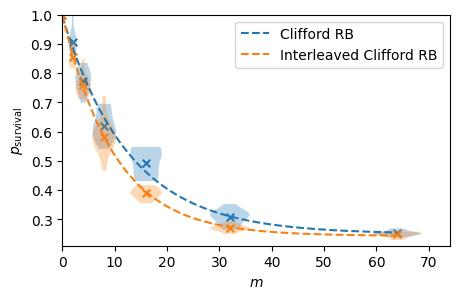

In [26]:
plt.figure(figsize=(5,3))
interleaved_rb.plot_rb_results()
plt.legend()
plt.show()

If you want to find the Clifford RB average gate error using the non-interleaved RB experiment, you may run the following: 

In [27]:
interleaved_rb.get_base_rb_average_gate_error()

The Clifford randomized benchmarking average gate error is 0.056791535558805784
